In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

titanic_data = pd.read_csv('C:/Users/Zharfan/Documents/Jupyter/titanic.csv', sep=';')

In [35]:
# Display the first few rows to understand the data
titanic_data.head()

# Check basic information about the dataset
titanic_data.info()

# Get statistical summary
titanic_data.describe()

# Check for missing values
titanic_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Passenger Class                     1309 non-null   object 
 1   Name                                1309 non-null   object 
 2   Sex                                 1309 non-null   object 
 3   Age                                 1046 non-null   float64
 4   No of Siblings or Spouses on Board  1309 non-null   int64  
 5   No of Parents or Children on Board  1309 non-null   int64  
 6   Ticket Number                       1309 non-null   object 
 7   Passenger Fare                      1308 non-null   object 
 8   Cabin                               295 non-null    object 
 9   Port of Embarkation                 1307 non-null   object 
 10  Life Boat                           486 non-null    object 
 11  Survived                            1309 no

Passenger Class                          0
Name                                     0
Sex                                      0
Age                                    263
No of Siblings or Spouses on Board       0
No of Parents or Children on Board       0
Ticket Number                            0
Passenger Fare                           1
Cabin                                 1014
Port of Embarkation                      2
Life Boat                              823
Survived                                 0
dtype: int64

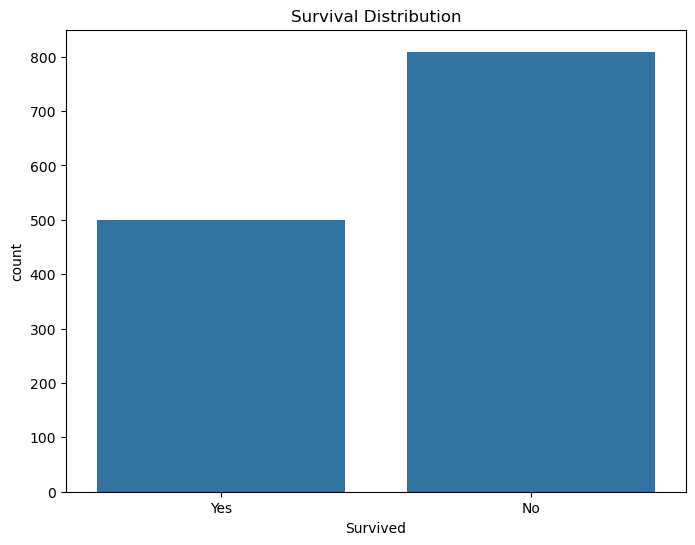

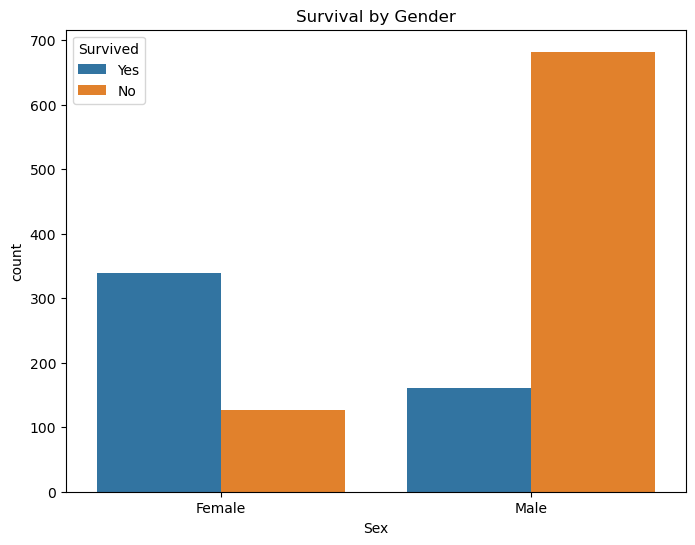

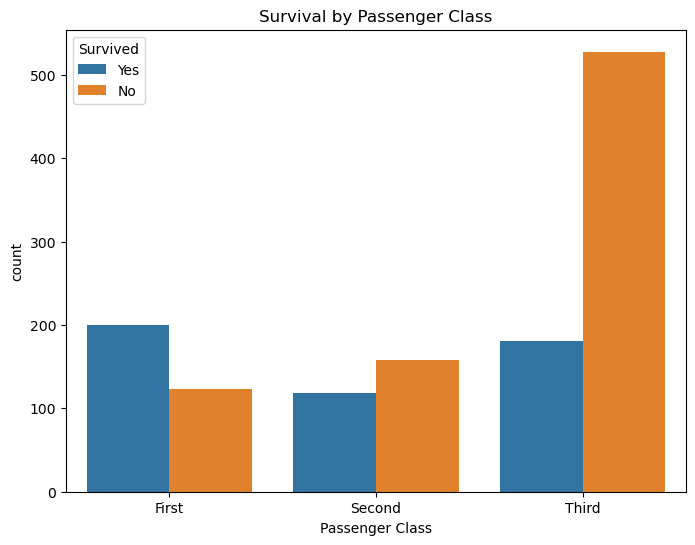

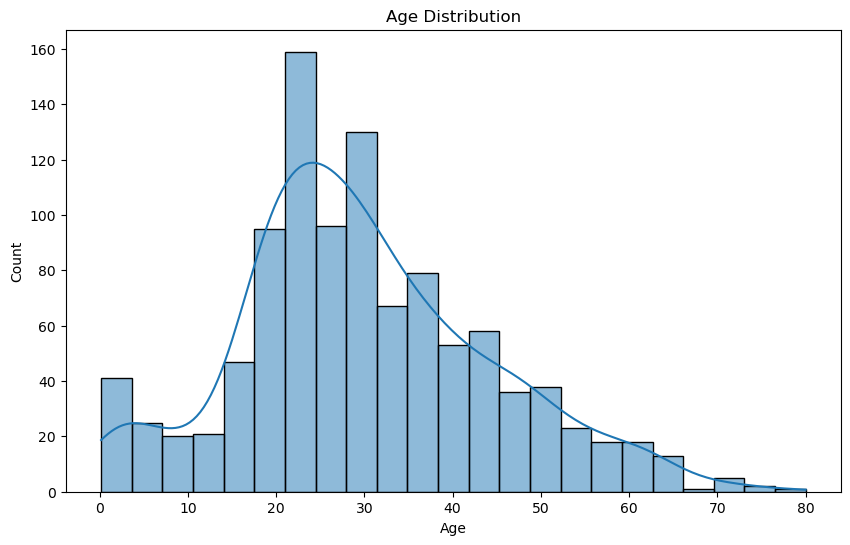

In [36]:
# Exploratory Data Analysis
# Survival distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=titanic_data)
plt.title('Survival Distribution')
plt.show()

# Survival by gender
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=titanic_data)
plt.title('Survival by Gender')
plt.show()

# Survival by passenger class
plt.figure(figsize=(8, 6))
sns.countplot(x='Passenger Class', hue='Survived', data=titanic_data)
plt.title('Survival by Passenger Class')
plt.show()

# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(titanic_data['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()


In [37]:
# Data Preprocessing
# Select relevant features
features = ['Passenger Class', 'Sex', 'Age', 'No of Siblings or Spouses on Board', 'No of Parents or Children on Board', 'Passenger Fare', 'Port of Embarkation']
X = titanic_data[['Passenger Class', 'Sex', 'Age', 'No of Siblings or Spouses on Board', 'No of Parents or Children on Board', 'Passenger Fare', 'Port of Embarkation']].copy()
y = titanic_data['Survived']

# Handle categorical features
X['Sex'] = X['Sex'].map({'Male': 0, 'Female': 1})
X['Port of Embarkation'] = X['Port of Embarkation'].map({'Cherbourg': 0, 'Queenstown': 1, 'Southampton': 2})

# Convert 'Passenger Fare' to numeric, forcing errors to NaN
X['Passenger Fare'] = pd.to_numeric(X['Passenger Fare'], errors='coerce')

# Handle missing values
imputer = SimpleImputer(strategy='median')
X['Age'] = imputer.fit_transform(X[['Age']])
X['Passenger Fare'] = imputer.fit_transform(X[['Passenger Fare']])
X['Port of Embarkation'] = X['Port of Embarkation'].fillna(X['Port of Embarkation'].mode()[0])

# Standardize numerical features
scaler = StandardScaler()
X[['Age', 'Passenger Fare']] = scaler.fit_transform(X[['Age', 'Passenger Fare']])

In [38]:
# Rename columns to match the original column names
X.rename(columns={
	'Passenger Class': 'Pclass',
	'No of Siblings or Spouses on Board': 'SibSp',
	'No of Parents or Children on Board': 'Parch',
	'Passenger Fare': 'Fare',
	'Port of Embarkation': 'Embarked'
}, inplace=True)

# Convert target variable to numerical values
y = titanic_data['Survived'].map({'Yes': 1, 'No': 0})

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:
X = titanic_data.drop('Survived', axis=1)  # replace target_column with your actual target column name
y = titanic_data['Survived'].map({'Yes': 1, 'No': 0})  # Convert target variable to numerical values

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Create a ColumnTransformer to handle missing values and One-Hot Encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), X.select_dtypes(include=['float64', 'int64']).columns),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='passthrough'  # Leave other columns untouched
)

# Build a pipeline with preprocessing + model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Age', 'No of Siblings or Spouses on Board',
       'No of Parents or Children on Board'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Passenger Class', 'Name', 'Sex', 'Ticket Number', 'Passenger Fare',
       'Cabin', 'Port of Embarkation', 'Life Boat'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [44]:
# Make predictions
y_pred_proba = model.predict(X_test)
# Convert to binary predictions (0 or 1)
y_pred = [1 if p >= 0.5 else 0 for p in y_pred_proba]

# Model Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9580

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       144
           1       1.00      0.91      0.95       118

    accuracy                           0.96       262
   macro avg       0.96      0.95      0.96       262
weighted avg       0.96      0.96      0.96       262



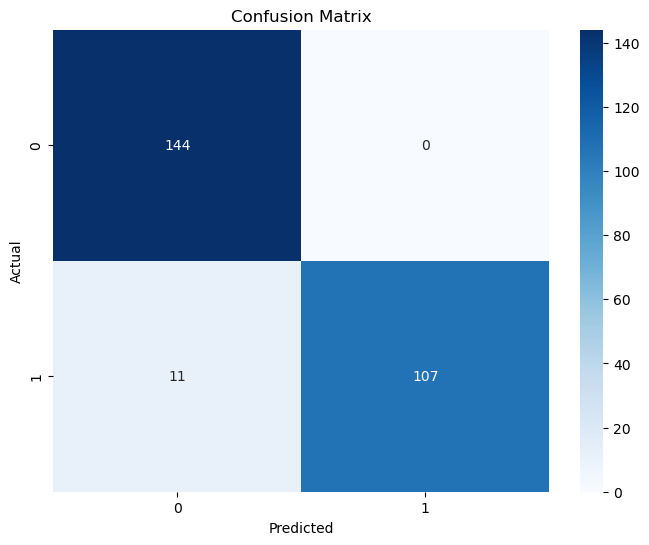

In [45]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()